## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
! git clone https://github.com/AngelikaBaloy/undergrad_ml_assignments/

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 183 (delta 68), reused 22 (delta 22), pack-reused 104 (from 2)
Receiving objects: 100% (183/183), 17.68 MiB | 9.78 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV, LinearRegression, lasso_path, Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler


In [22]:
# 1. Load golub data
df = pd.read_csv('undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,AFFX-BioB-M_st,AFFX-BioB-3_st,AFFX-BioC-5_st,AFFX-BioC-3_st,AFFX-BioDn-5_st,AFFX-BioDn-3_st,AFFX-CreX-5_st,AFFX-CreX-3_st,hum_alu_at,AFFX-DapX-5_at,AFFX-DapX-M_at,AFFX-DapX-3_at,AFFX-LysX-5_at,AFFX-LysX-M_at,AFFX-LysX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-PheX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-ThrX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,AFFX-TrpnX-3_at,...,X53065_f_at,X64177_f_at,X67491_f_at,X71345_f_at,X97444_f_at,Z80780_f_at,X00351_f_at,X01677_f_at,M31667_f_at,L41268_f_at,X99479_f_at,HG658-HT658_f_at,M94880_f_at,S80905_f_at,X03068_f_at,Z34822_f_at,U87593_f_at,U88902_cds1_f_at,AC002076_cds2_at,D64015_at,HG2510-HT2606_at,L10717_at,L34355_at,L78833_cds4_at,M13981_at,M21064_at,M93143_at,S78825_at,U11863_at,U29175_at,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,-1110.082554,-1545.661845,-2037.029616,-1255.990888,-335.480958,-938.425691,-526.449219,-1897.558414,-1964.075449,-1363.276427,1.395636,-112.327036,-644.463312,-861.180102,97676.296572,-507.137821,276.046617,-1026.399833,-732.437455,-1017.816990,-638.026180,-912.677161,-633.734758,-382.686596,-541.469194,-736.728876,-1062.876916,-386.978017,-1824.604247,-2103.546650,...,291.066593,-1927.598365,-633.734758,664.420271,188.072475,4595.362441,44039.963919,26983.708838,1162.225174,203.092450,-882.637210,34680.373447,25340.094372,338.272230,6320.513917,-1384.733535,-541.469194,544.260466,-736.728876,-294.712453,-541.469194,-588.674832,63.621249,271.755196,-133.784144,-101.598482,514.220515,-846.160127,-1597.158904,3902.297855,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,-1116.432539,-1731.392100,249.376523,-1636.960108,-149.080421,-222.783440,-119.138570,-2806.995527,-2028.507394,-192.841588,-202.054466,-759.433543,-971.329722,-1620.837572,47674.965728,-547.537365,-280.363923,-787.072175,-526.808391,-409.344205,95.060828,-770.949640,-1134.858294,-708.762718,-540.627707,-715.672376,-1448.096123,-676.517648,-2014.688078,-1537.921677,...,-340.247625,-2079.178219,-326.428309,-817.014027,67.422196,-648.879016,21282.375436,40756.094863,714.626827,39.783564,-1123.342197,42621.702520,23240.111866,-126.048228,22166.811658,-1296.083647,-846.955878,286.228032,-625.846822,101.970486,-326.428309,-395.524889,-922.962116,-107.622473,-584.388874,152.641311,-411.647425,-1788.972583,-6137.450677,2451.254201,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,-1199.319178,-1286.387935,-605.465604,-1043.041921,-728.254877,388.011238,-598.768008,-1882.474040,-781.835650,-949.275568,-699.231958,-900.159859,-1134.575743,-1063.134712,57049.679245,-636.721056,-571.977621,-755.045264,-645.651184,-761.742860,-618.860798,-844.346553,-996.158745,-779.603118,-810.858569,-884.532133,-1295.318063,-614.395733,-1487.315835,-1060.902179,...,-313.003882,-2447.304694,338.895529,106.712177,82.154323,492.940253,45005.167862,37452.511327,2359.337198,-513.931783,-306.306285,35394.116610,41888.552869,-714.859684,1589.113578,-1020.716599,-645.651184,64.294065,-694.766894,-328.631608,-534.024573,-556.349895,-299.608689,-203.609803,-516.164315,-306.306285,-185.749545,-1150.203469,-9010.949452,1115.816745,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,-1264.607160,-1218.860503,-1255.893511,-1009.732928,-521.768585,-926.953263,-940.023736,-1334.316352,-1591.368997,-959.629446,-

In [23]:
# relabel ALLB & ALLT as 0; ALL as 1 (target variable)
df['cancer'].unique()

mapper = {'allB': 0,
          'allT': 0,
          'aml': 1}
df['y'] = df['cancer'].map(mapper) # making new col
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,AFFX-BioB-5_st,AFFX-BioB-M_st,AFFX-BioB-3_st,AFFX-BioC-5_st,AFFX-BioC-3_st,AFFX-BioDn-5_st,AFFX-BioDn-3_st,AFFX-CreX-5_st,AFFX-CreX-3_st,hum_alu_at,AFFX-DapX-5_at,AFFX-DapX-M_at,AFFX-DapX-3_at,AFFX-LysX-5_at,AFFX-LysX-M_at,AFFX-LysX-3_at,AFFX-PheX-5_at,AFFX-PheX-M_at,AFFX-PheX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-ThrX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,AFFX-TrpnX-3_at,...,X64177_f_at,X67491_f_at,X71345_f_at,X97444_f_at,Z80780_f_at,X00351_f_at,X01677_f_at,M31667_f_at,L41268_f_at,X99479_f_at,HG658-HT658_f_at,M94880_f_at,S80905_f_at,X03068_f_at,Z34822_f_at,U87593_f_at,U88902_cds1_f_at,AC002076_cds2_at,D64015_at,HG2510-HT2606_at,L10717_at,L34355_at,L78833_cds4_at,M13981_at,M21064_at,M93143_at,S78825_at,U11863_at,U29175_at,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,y
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,-1110.082554,-1545.661845,-2037.029616,-1255.990888,-335.480958,-938.425691,-526.449219,-1897.558414,-1964.075449,-1363.276427,1.395636,-112.327036,-644.463312,-861.180102,97676.296572,-507.137821,276.046617,-1026.399833,-732.437455,-1017.816990,-638.026180,-912.677161,-633.734758,-382.686596,-541.469194,-736.728876,-1062.876916,-386.978017,-1824.604247,-2103.546650,...,-1927.598365,-633.734758,664.420271,188.072475,4595.362441,44039.963919,26983.708838,1162.225174,203.092450,-882.637210,34680.373447,25340.094372,338.272230,6320.513917,-1384.733535,-541.469194,544.260466,-736.728876,-294.712453,-541.469194,-588.674832,63.621249,271.755196,-133.784144,-101.598482,514.220515,-846.160127,-1597.158904,3902.297855,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092,0
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,-1116.432539,-1731.392100,249.376523,-1636.960108,-149.080421,-222.783440,-119.138570,-2806.995527,-2028.507394,-192.841588,-202.054466,-759.433543,-971.329722,-1620.837572,47674.965728,-547.537365,-280.363923,-787.072175,-526.808391,-409.344205,95.060828,-770.949640,-1134.858294,-708.762718,-540.627707,-715.672376,-1448.096123,-676.517648,-2014.688078,-1537.921677,...,-2079.178219,-326.428309,-817.014027,67.422196,-648.879016,21282.375436,40756.094863,714.626827,39.783564,-1123.342197,42621.702520,23240.111866,-126.048228,22166.811658,-1296.083647,-846.955878,286.228032,-625.846822,101.970486,-326.428309,-395.524889,-922.962116,-107.622473,-584.388874,152.641311,-411.647425,-1788.972583,-6137.450677,2451.254201,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577,0
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,-1199.319178,-1286.387935,-605.465604,-1043.041921,-728.254877,388.011238,-598.768008,-1882.474040,-781.835650,-949.275568,-699.231958,-900.159859,-1134.575743,-1063.134712,57049.679245,-636.721056,-571.977621,-755.045264,-645.651184,-761.742860,-618.860798,-844.346553,-996.158745,-779.603118,-810.858569,-884.532133,-1295.318063,-614.395733,-1487.315835,-1060.902179,...,-2447.304694,338.895529,106.712177,82.154323,492.940253,45005.167862,37452.511327,2359.337198,-513.931783,-306.306285,35394.116610,41888.552869,-714.859684,1589.113578,-1020.716599,-645.651184,64.294065,-694.766894,-328.631608,-534.024573,-556.349895,-299.608689,-203.609803,-516.164315,-306.306285,-185.749545,-1150.203469,-9010.949452,1115.816745,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231,0
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,-1264.607160,-1218.860503,-1255.893511,-1009.732928,-521.768585,-926.953263,-940.023736,-1334.316352,-1591.368997,-959.629446,-757.037108,-380.171789,-702.576802,-116

In [32]:
# 2. Use LR on all the genes
genes = df.drop(columns= ['y', 'cancer',
                          'Samples', 'BM.PB',
                          'Gender', 'Source',
                          'tissue.mf'])
y = df['y']

model = LinearRegression()
model.fit(genes, y)

y_hat = model.predict(genes)

# mean squared error
mse = mean_squared_error(y, y_hat)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 1.2522824482837894e-30


Text(0.5, 0, 'Residuals')

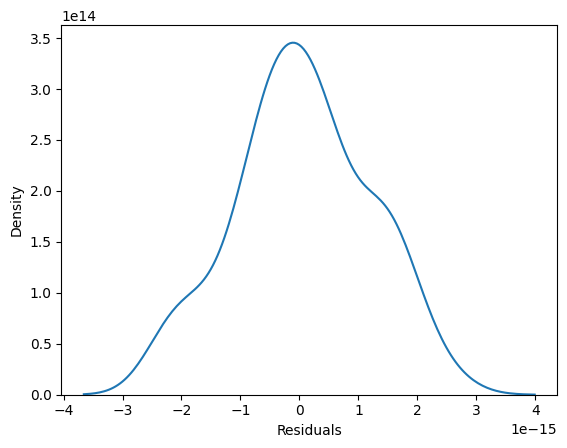

In [31]:
# kdeplot of residuals

sns.kdeplot(y - y_hat)
plt.xlabel("Residuals")

<Axes: xlabel='y'>

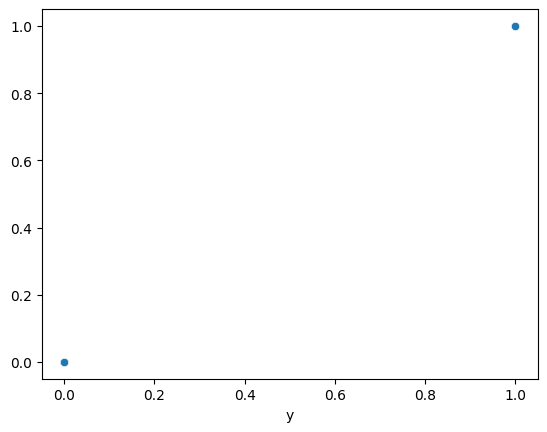

In [27]:
# scatter plot comparing predicted and actual outcomes

sns.scatterplot(x=y, y=y_hat)
# 0 and 1 are the only options so

In [35]:
# 3. Cross validation

model = LinearRegression()
model.fit(genes, y)

y_hat = model.predict(genes)

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # going with 10 folds

mse_scorer = make_scorer(mean_squared_error)
scores = cross_val_score(
    model, genes, y,
    cv=kfold,
    scoring=mse_scorer
)

print("Fold scores", scores)
print("Mean score", np.mean(scores))
print("Median score", np.median(scores))
print("Std dev", np.std(scores))

# Results:
# It appears that the model is performing well, with low variance and little bias in predictions.
# Of course, some folds perform better than others. But predictions are relatively consistent
# and predictions are mostly correct.
# Since there are a lot of genes/predictor variables, there's ultimately a lot of noise.

Fold scores [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean score 0.045876895088525556
Median score 0.03573571993995745
Std dev 0.027037144984588028


In [ ]:
# 4. LASSO to select highly predictive genes

alpha_grid = np.logspace(-3, 0, 15) # Create a grid of alpha values
coefs = []
for alpha in alpha_grid: # For each alpha value,
    model = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    model = model.fit(X,y) # Run the regression
    coefs.append(model.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array
var_names = model.feature_names_in_ # Get variable names

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=var_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [39]:
alpha_grid = np.logspace(-7, 0, 25)
coefs=[]
for alpha in alpha_grid:
  model= Lasso(alpha=alpha, max_iter=10_000)
  model = model.fit(genes, y)
  coefs.append(model.coef_)
coefs= np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
  plt.plot(alpha_grid, coefs[:, i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

KeyboardInterrupt: 

In [37]:
scaler = StandardScaler()
genes_scaled = scaler.fit_transform(genes)

alpha_grid = np.logspace(-7, -5, num=50)
model = LassoCV(alphas=alpha_grid,
                cv=10,
                random_state=100)
model = model.fit(genes_scaled, y)

sns.lineplot(x=alpha_grid, y=)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.720e-03, tolerance: 1.523e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.817e-03, tolerance: 1.523e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.828e-03, tolerance: 1.523e